# RSA Searchlight Results

Whole-brain searchlight RSA: 5-term regression (category, value, frequency,
second_stim_value, choice_rate) at every voxel sphere (6 mm radius) on
crossnobis distances from GLMsingle single-trial betas, non-figure subset
(6 stimuli).

Produced by `run_rsa_searchlight.py`. Each subject yields 5 beta maps;
group inference is a one-sample t-test against 0 (crossnobis is unbiased
under the null).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
import nibabel as nib
from nilearn import image, plotting
from nilearn.image import resample_to_img, index_img
from nilearn.reporting import get_clusters_table
from IPython.display import display as ipy_display

RSA_SL_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/derivatives/rsa_searchlight")
DERIV_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/derivatives")
SL_DIR = DERIV_DIR / "searchlight"  # frequency/category searchlight maps
MASK_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/masks/MNI152NLin2009cAsym")

MASKS = {
    "visualcortex": DERIV_DIR / "decoding" / "visual_cortex_mask.nii.gz",
    "fusiform": MASK_DIR / "fusiform_mask_MNI152NLin2009cAsym.nii",
    "vmpfc": MASK_DIR / "vmpfc_bartra2013_MNI152NLin2009cAsym.nii",
    "striatum": MASK_DIR / "striatum_bartra2013_MNI152NLin2009cAsym.nii",
    "habit": MASK_DIR / "habit_Guida2022_MNI152NLin2009cAsym.nii",
    "putamen": MASK_DIR / "putamen_AAL_MNI152NLin2009cAsym.nii",
    "premotor": MASK_DIR / "premotor_HMAT_MNI152NLin2009cAsym.nii",
    "parietal": MASK_DIR / "parietal_AAL_MNI152NLin2009cAsym.nii",
}
MASK_LABELS = {
    "visualcortex": "Visual cortex", "fusiform": "Fusiform",
    "vmpfc": "vmPFC", "striatum": "Striatum",
    "habit": "Habit (Guida)", "putamen": "Putamen",
    "premotor": "Premotor", "parietal": "Parietal",
}

TERMS = ["category", "value", "frequency", "second_stim_value", "choice_rate"]
TERM_LABELS = {
    "category": "Category", "value": "Value", "frequency": "Frequency",
    "second_stim_value": "2nd stim value", "choice_rate": "Choice rate",
}

## 1. Data Loading & Completeness Check

In [2]:
# Discover per-subject beta maps for each term
term_imgs = {}   # {term: [nib images in subject order]}
subjects = None

for term in TERMS:
    paths = sorted(RSA_SL_DIR.glob(f"sub-*/sub-*_rsa_searchlight_beta_{term}.nii.gz"))
    sids = [p.parent.name.replace("sub-", "") for p in paths]
    if subjects is None:
        subjects = sids
    else:
        assert sids == subjects, f"Subject mismatch for {term}"
    term_imgs[term] = [nib.load(str(p)) for p in paths]

print(f"Found {len(subjects)} subjects × {len(TERMS)} terms = {len(subjects)*len(TERMS)} maps")
print(f"Subjects: {', '.join(subjects[:10])}...")

# Concat each term into a 4D image
term_4d = {term: image.concat_imgs(imgs) for term, imgs in term_imgs.items()}
print(f"4D shape: {term_4d['frequency'].shape}")

Found 58 subjects × 5 terms = 290 maps
Subjects: 01, 02, 03, 05, 06, 07, 08, 09, 10, 12...


4D shape: (53, 65, 48, 58)


## 2. Group Inference: Voxelwise t-tests vs. 0

One-sample t-test at each voxel against 0 for each model term, followed by
FDR correction (Benjamini-Hochberg, q < 0.05). Crossnobis distances are
unbiased under the null, so β = 0 is the correct null.

In [3]:
# Build brain mask (voxels finite in all subjects for all terms)
ref_data = term_4d["frequency"].get_fdata()
brain_mask = np.all(np.isfinite(ref_data), axis=3)
for term in TERMS:
    d = term_4d[term].get_fdata()
    brain_mask &= np.all(np.isfinite(d), axis=3)

n_brain = brain_mask.sum()
print(f"Brain voxels present in all subjects (all terms): {n_brain:,}")

# Run t-tests for each term
affine = term_4d["frequency"].affine
header = term_4d["frequency"].header

term_results = {}  # {term: {t_img, t_fdr_img, n_sig, n_pos, n_neg}}

for term in TERMS:
    data = term_4d[term].get_fdata()
    vals = data[brain_mask]  # (n_voxels, n_subjects)
    t_vals, p_vals = stats.ttest_1samp(vals, 0, axis=1)

    reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')
    n_sig = reject.sum()
    n_pos = (reject & (t_vals > 0)).sum()
    n_neg = (reject & (t_vals < 0)).sum()

    # Build maps
    t_map = np.zeros(brain_mask.shape)
    t_map[brain_mask] = t_vals
    t_img = nib.Nifti1Image(t_map, affine, header)

    t_fdr = np.zeros(brain_mask.shape)
    t_fdr[brain_mask] = np.where(reject, t_vals, 0)
    t_fdr_img = nib.Nifti1Image(t_fdr, affine, header)

    term_results[term] = {
        "t_img": t_img, "t_fdr_img": t_fdr_img,
        "n_sig": n_sig, "n_pos": n_pos, "n_neg": n_neg,
        "t_vals": t_vals, "p_vals": p_vals, "reject": reject,
    }

    print(f"{TERM_LABELS[term]:>16s}: {n_sig:,} FDR-sig voxels "
          f"({100*n_sig/n_brain:.1f}%)  [+{n_pos:,} / −{n_neg:,}]")

Brain voxels present in all subjects (all terms): 165,360


        Category: 0 FDR-sig voxels (0.0%)  [+0 / −0]


           Value: 0 FDR-sig voxels (0.0%)  [+0 / −0]


       Frequency: 2,945 FDR-sig voxels (1.8%)  [+2,926 / −19]


  2nd stim value: 4 FDR-sig voxels (0.0%)  [+3 / −1]


     Choice rate: 0 FDR-sig voxels (0.0%)  [+0 / −0]


## 3. FDR-thresholded t-maps — main terms

Focus on the three main predictors: frequency, value, and category.

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/1798337188.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


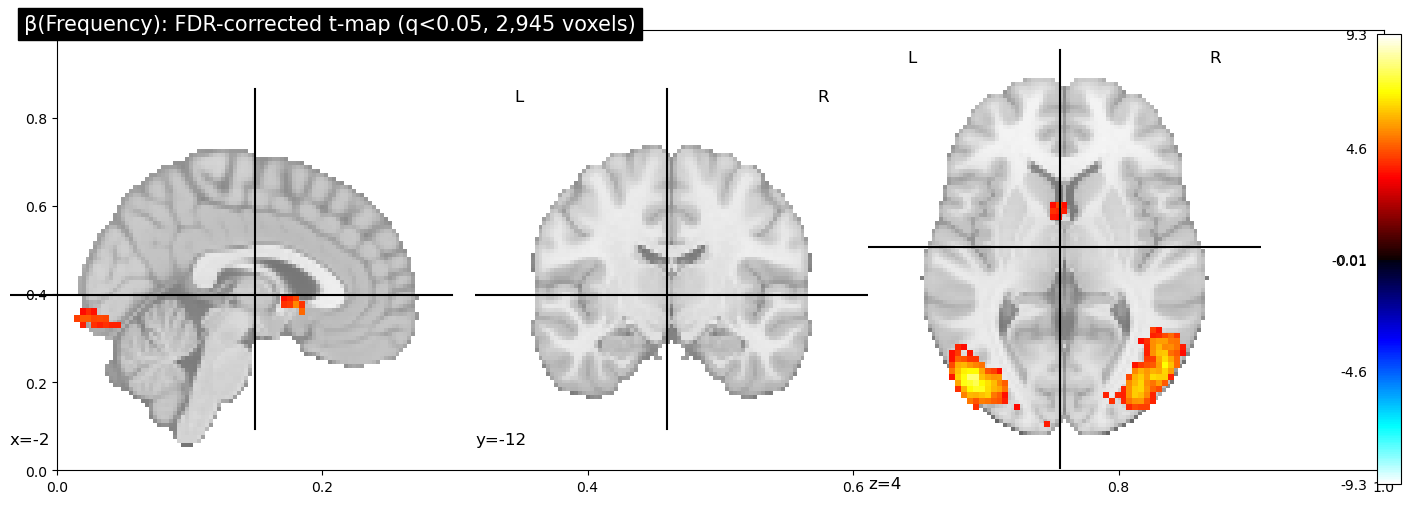

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/1798337188.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


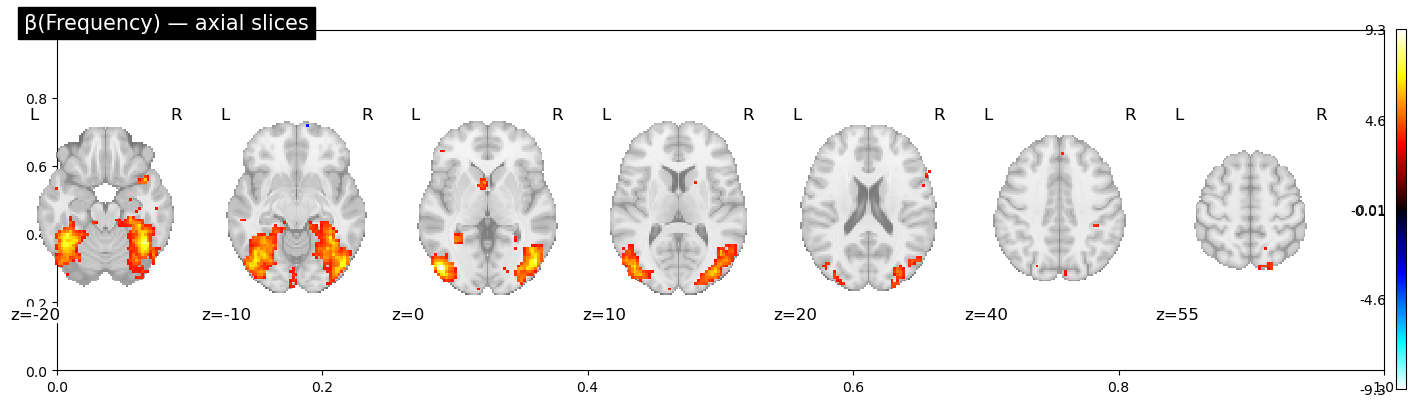

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/1798337188.py:10: UserWarning: empty mask
  plotting.plot_stat_map(


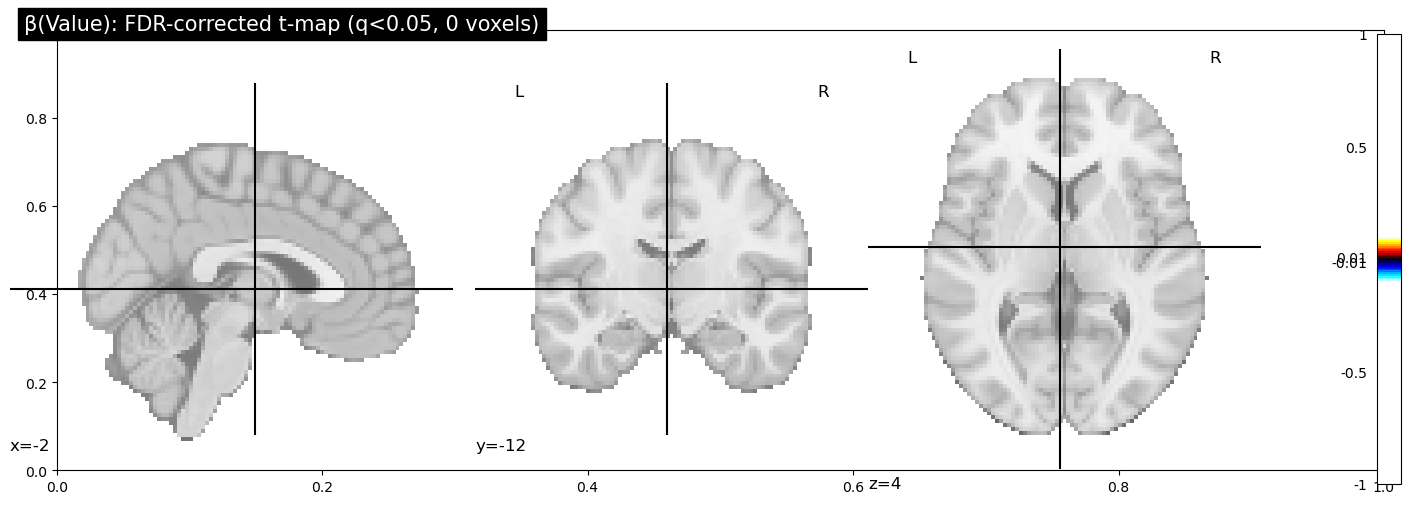

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/1798337188.py:22: UserWarning: empty mask
  plotting.plot_stat_map(


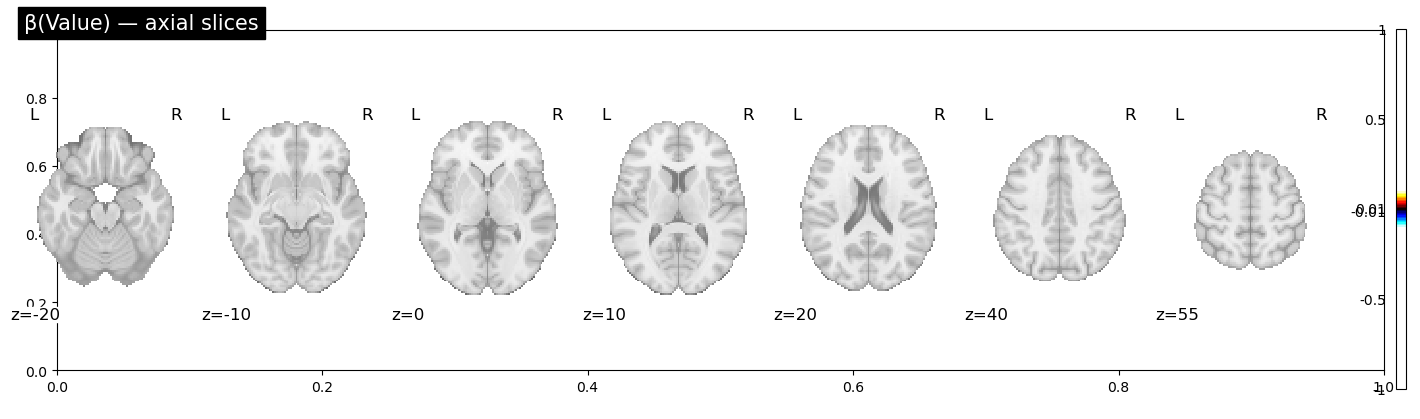

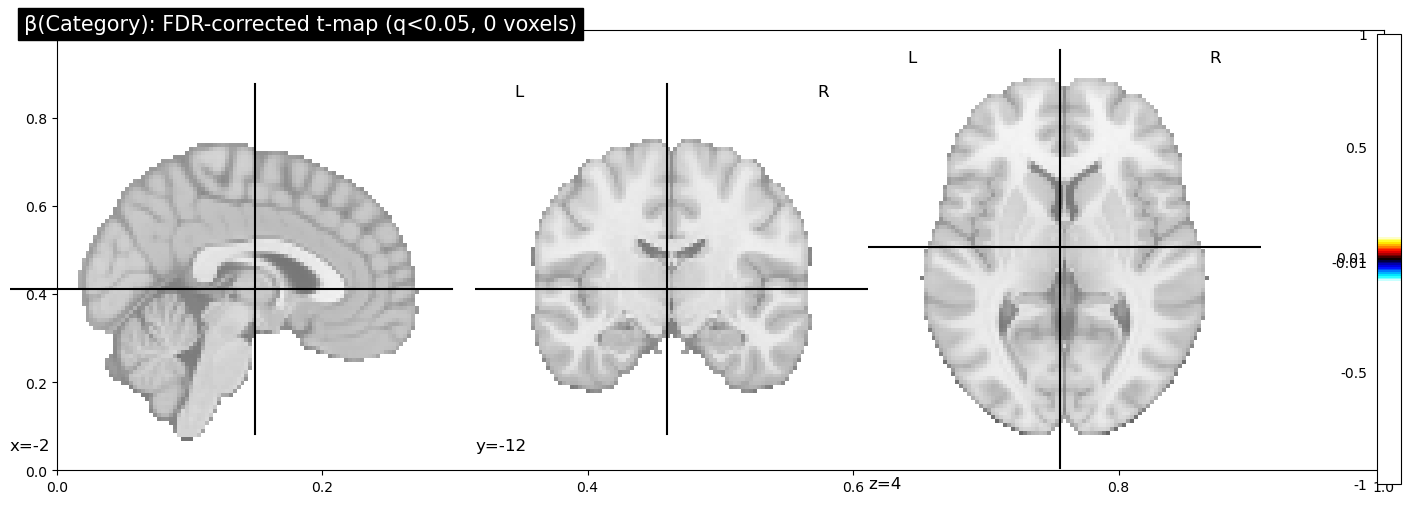

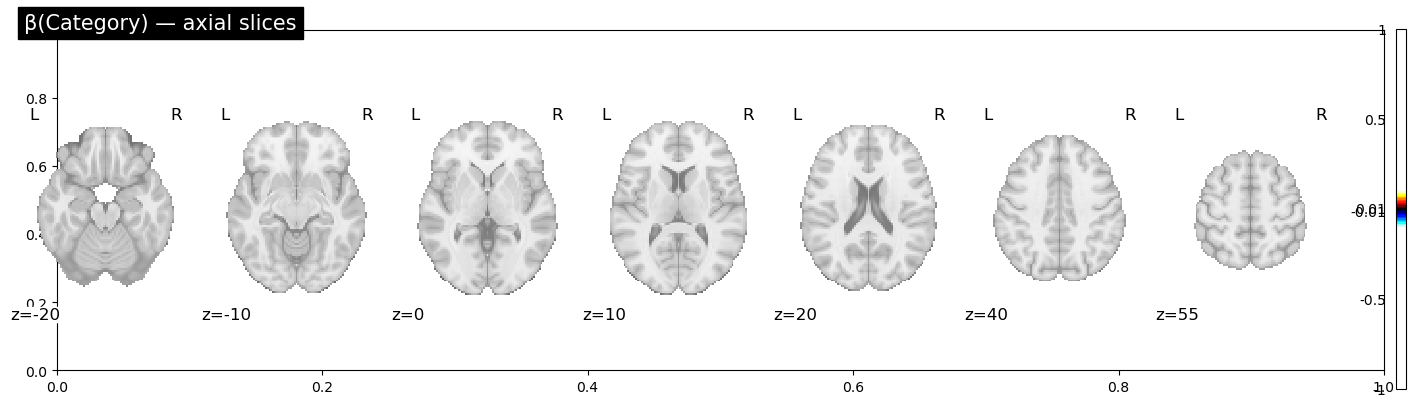

In [4]:
main_terms = ["frequency", "value", "category"]

for term in main_terms:
    res = term_results[term]
    n_sig = res["n_sig"]
    label = TERM_LABELS[term]

    # Ortho view
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    plotting.plot_stat_map(
        res["t_fdr_img"], threshold=0.01,
        title=f"β({label}): FDR-corrected t-map (q<0.05, {n_sig:,} voxels)",
        cut_coords=(-2, -12, 4), display_mode="ortho",
        cmap="cold_hot",
        figure=fig,
    )
    plt.tight_layout()
    plt.show()

    # Axial slices
    fig2, ax2 = plt.subplots(1, 1, figsize=(14, 4))
    plotting.plot_stat_map(
        res["t_fdr_img"], threshold=0.01,
        title=f"β({label}) — axial slices",
        display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
        cmap="cold_hot",
        figure=fig2,
    )
    plt.tight_layout()
    plt.show()

## 4. Peak Coordinates — Frequency

Cluster table for the frequency β map (the main result of interest).

In [5]:
for term in main_terms:
    res = term_results[term]
    label = TERM_LABELS[term]
    if res["n_sig"] == 0:
        print(f"\n{label}: no FDR-significant voxels — skipping.\n")
        continue

    sig_t = np.abs(res["t_vals"][res["reject"]])
    t_thresh = sig_t.min()
    print(f"\n{label}: FDR threshold corresponds to |t| >= {t_thresh:.2f}")

    clusters = get_clusters_table(
        res["t_img"], stat_threshold=t_thresh, min_distance=12,
        cluster_threshold=10,
    )
    print(f"{len(clusters)} peaks found:")
    ipy_display(clusters.head(25))


Frequency: FDR threshold corresponds to |t| >= 3.51
15 peaks found:


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/3526270980.py:12: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  clusters = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-48.0,-81.0,-1.0,9.293626,36855
1,1a,-39.0,-45.0,-18.5,7.594847,
2,1b,-39.0,-60.0,-15.0,7.347949,
3,1c,-45.0,-72.0,13.0,6.065266,
4,2,42.0,-54.0,-18.5,8.486008,47187
5,2a,51.0,-72.0,-1.0,7.942907,
6,2b,39.0,-42.0,-15.0,7.562986,
7,2c,39.0,-84.0,6.0,7.148367,
8,3,42.0,12.0,-18.5,6.258796,504
9,4,-24.0,-81.0,34.0,5.660288,1417



Value: no FDR-significant voxels — skipping.


Category: no FDR-significant voxels — skipping.



## 5. ROI Mean β

Mean searchlight β within each ROI mask — bridges the searchlight and
ROI-level RSA analyses. Direct comparison with `rsa_roi_results.ipynb`.

In [6]:
# Load and resample ROI masks to searchlight space
ref_img = term_imgs["frequency"][0]

def load_roi_mask(mask_path, ref_img):
    roi_mni = nib.load(str(mask_path))
    roi_func = resample_to_img(roi_mni, ref_img, interpolation='nearest')
    if roi_func.ndim == 4 and roi_func.shape[3] == 1:
        roi_func = index_img(roi_func, 0)
    return roi_func.get_fdata() > 0

roi_masks_arr = {}
for name, path in MASKS.items():
    if path.exists():
        roi_masks_arr[name] = load_roi_mask(path, ref_img)
    else:
        print(f"WARNING: mask not found: {name} -> {path}")

# Compute per-subject mean β within each ROI, for each term
roi_rows = []
for term in TERMS:
    data = term_4d[term].get_fdata()
    for name, mask_arr in roi_masks_arr.items():
        roi_brain = mask_arr & brain_mask
        n_vox = roi_brain.sum()
        for i, sid in enumerate(subjects):
            subj_vals = data[:, :, :, i][roi_brain]
            roi_rows.append({
                "subject": sid, "roi": name, "term": term,
                "mean_beta": subj_vals.mean() if len(subj_vals) > 0 else np.nan,
                "n_voxels": n_vox,
            })

roi_df = pd.DataFrame(roi_rows)

# Group-level stats: t-test against 0 for each (term, ROI)
roi_stats_rows = []
for term in TERMS:
    for name in roi_masks_arr:
        betas = roi_df.loc[(roi_df["term"] == term) & (roi_df["roi"] == name), "mean_beta"].values
        t, p = stats.ttest_1samp(betas, 0)
        roi_stats_rows.append({
            "term": TERM_LABELS[term], "ROI": MASK_LABELS.get(name, name),
            "n_voxels": roi_masks_arr[name].sum(),
            "mean_beta": betas.mean(), "std": betas.std(),
            "t": t, "p": p, "n": len(betas),
        })

roi_stats = pd.DataFrame(roi_stats_rows)

# FDR across all (term × ROI) tests
_, roi_stats["p_fdr"], _, _ = multipletests(roi_stats["p"], alpha=0.05, method="fdr_bh")
roi_stats["sig"] = roi_stats["p_fdr"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")

print("FDR correction across all term × ROI tests:")
ipy_display(roi_stats.round(4))

FDR correction across all term × ROI tests:


,term,ROI,n_voxels,mean_beta,std,t,p,n,p_fdr,sig
0,Category,Visual cortex,7799,0.0074,0.0993,0.5637,0.5752,58,0.8217,
1,Category,Fusiform,320,0.0144,0.1597,0.6802,0.4991,58,0.7394,
2,Category,vmPFC,119,0.0170,0.1471,0.8705,0.3877,58,0.5964,
3,Category,Striatum,128,0.0191,0.1167,1.2357,0.2217,58,0.4290,
4,Category,Habit (Guida),657,0.0236,0.0806,2.2130,0.0309,58,0.1374,
5,Category,Putamen,500,0.0252,0.0905,2.1001,0.0402,58,0.1606,
6,Category,Premotor,4412,0.0047,0.0821,0.4300,0.6688,58,0.8917,
7,Category,Parietal,2885,-0.0159,0.0995,-1.2092,0.2316,58,0.4290,
8,Value,Visual cortex,7799,-0.0233,0.0890,-1.9720,0.0535,58,0.1782,
9,Value,Fusiform,320,-0.0486,0.1300,-2.8216,0.0066,58,0.0501,


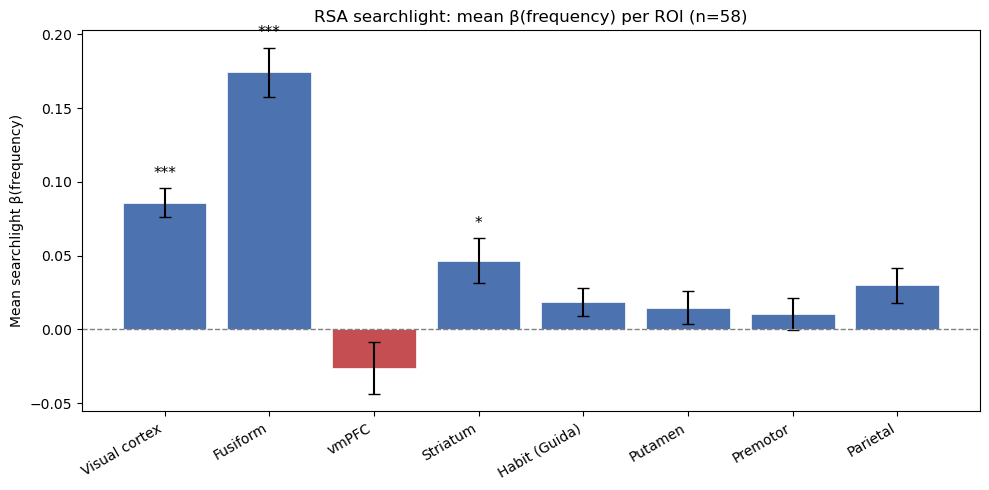

In [7]:
# Bar chart: frequency β per ROI (primary result)
freq_stats = roi_stats[roi_stats["term"] == "Frequency"].copy()
roi_order = list(roi_masks_arr.keys())
roi_labels = [MASK_LABELS.get(r, r) for r in roi_order]

means = [freq_stats.loc[freq_stats["ROI"] == MASK_LABELS.get(r, r), "mean_beta"].values[0] for r in roi_order]
sems = [roi_df.loc[(roi_df["roi"] == r) & (roi_df["term"] == "frequency"), "mean_beta"].std() / np.sqrt(len(subjects))
        for r in roi_order]
sigs = [freq_stats.loc[freq_stats["ROI"] == MASK_LABELS.get(r, r), "sig"].values[0] for r in roi_order]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4C72B0" if m > 0 else "#C44E52" for m in means]
bars = ax.bar(roi_labels, means, yerr=sems, capsize=4, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="grey", ls="--", lw=1)
for i, (bar, sig) in enumerate(zip(bars, sigs)):
    if sig:
        y = bar.get_height() + sems[i] + 0.005 if bar.get_height() > 0 else bar.get_height() - sems[i] - 0.015
        ax.text(bar.get_x() + bar.get_width()/2, y, sig, ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Mean searchlight β(frequency)")
ax.set_title("RSA searchlight: mean β(frequency) per ROI (n=58)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Comparison with Frequency Decoding Searchlight

Spatial correlation between the RSA β(frequency) t-map and the frequency
classification searchlight t-map — are they picking up the same signal?

Found 58 frequency decoding searchlight maps


Spatial correlation (t-maps, 51,733 voxels): r = 0.733, p = 0.00e+00


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/576181161.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


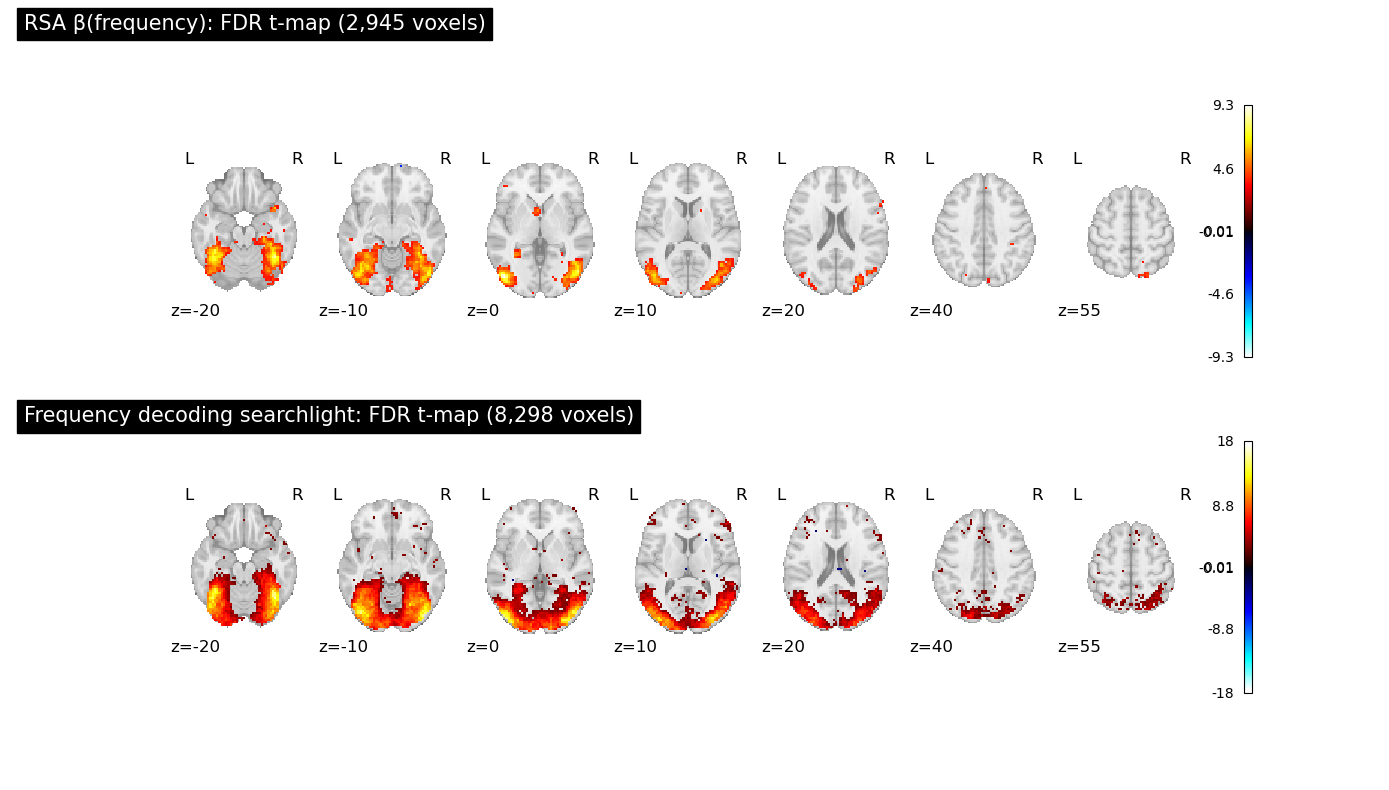

In [8]:
# Load frequency decoding searchlight maps
freq_dec_paths = sorted(SL_DIR.glob("sub-*/sub-*_searchlight_frequency.nii.gz"))

if freq_dec_paths:
    print(f"Found {len(freq_dec_paths)} frequency decoding searchlight maps")
    freq_dec_imgs = [nib.load(str(p)) for p in freq_dec_paths]
    freq_dec_4d = image.concat_imgs(freq_dec_imgs)
    freq_dec_data = freq_dec_4d.get_fdata()

    # T-test vs chance (0.5) for the decoding searchlight
    dec_brain = np.all(freq_dec_data > 0, axis=3)
    shared_mask = brain_mask & dec_brain
    dec_vals = freq_dec_data[shared_mask]
    dec_t, dec_p = stats.ttest_1samp(dec_vals, 0.5, axis=1)

    # RSA frequency t-values on the same mask
    rsa_freq_t = term_results["frequency"]["t_img"].get_fdata()[shared_mask]

    r, p_corr = stats.pearsonr(rsa_freq_t, dec_t)
    print(f"Spatial correlation (t-maps, {shared_mask.sum():,} voxels): r = {r:.3f}, p = {p_corr:.2e}")

    # Side-by-side t-maps
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    plotting.plot_stat_map(
        term_results["frequency"]["t_fdr_img"], threshold=0.01,
        title=f"RSA β(frequency): FDR t-map ({term_results['frequency']['n_sig']:,} voxels)",
        display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
        cmap="cold_hot", axes=axes[0],
    )

    # Build decoding FDR t-map for comparison
    dec_reject, _, _, _ = multipletests(dec_p, alpha=0.05, method='fdr_bh')
    dec_t_fdr = np.zeros(brain_mask.shape)
    dec_t_fdr[shared_mask] = np.where(dec_reject, dec_t, 0)
    dec_t_fdr_img = nib.Nifti1Image(dec_t_fdr, affine, header)
    n_dec_sig = dec_reject.sum()

    plotting.plot_stat_map(
        dec_t_fdr_img, threshold=0.01,
        title=f"Frequency decoding searchlight: FDR t-map ({n_dec_sig:,} voxels)",
        display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
        cmap="cold_hot", axes=axes[1],
    )
    plt.tight_layout()
    plt.show()
else:
    print("No frequency decoding searchlight maps found — skipping comparison.")

## 7. Confound term maps

Show the second_stim_value and choice_rate maps — these are confound
regressors, so significant clusters would need interpretation.

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/3806913494.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


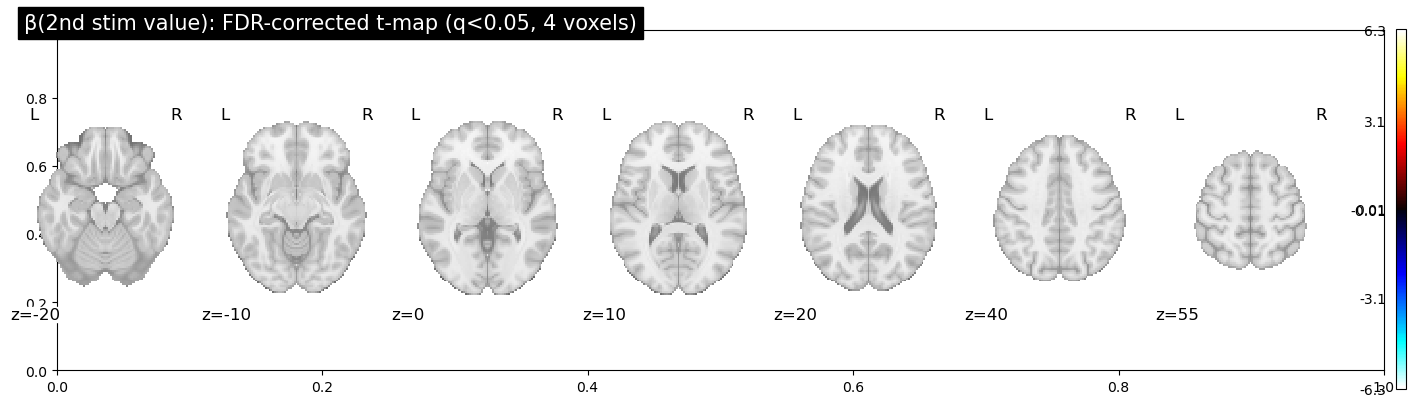

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/3806913494.py:17: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(


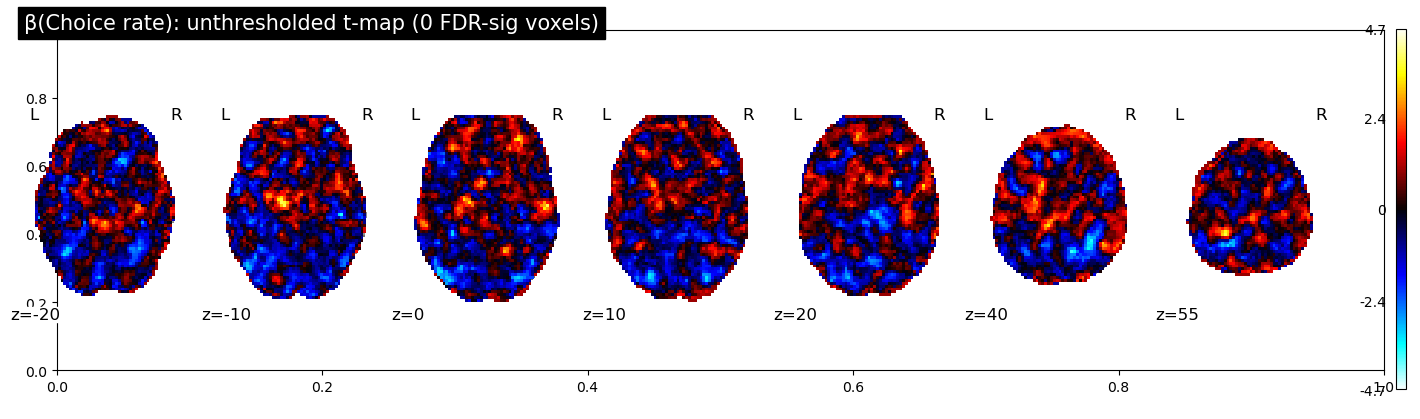

In [9]:
confound_terms = ["second_stim_value", "choice_rate"]

for term in confound_terms:
    res = term_results[term]
    label = TERM_LABELS[term]
    n_sig = res["n_sig"]

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    if n_sig > 0:
        plotting.plot_stat_map(
            res["t_fdr_img"], threshold=0.01,
            title=f"β({label}): FDR-corrected t-map (q<0.05, {n_sig:,} voxels)",
            display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
            cmap="cold_hot", figure=fig,
        )
    else:
        plotting.plot_stat_map(
            res["t_img"],
            title=f"β({label}): unthresholded t-map (0 FDR-sig voxels)",
            display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
            cmap="cold_hot", figure=fig,
        )
    plt.tight_layout()
    plt.show()

## 8. Glass brains — frequency, value, category side-by-side

Three-panel glass brain for a compact overview of the main terms.

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/3867580086.py:8: UserWarning: empty mask
  plotting.plot_glass_brain(


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/3867580086.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


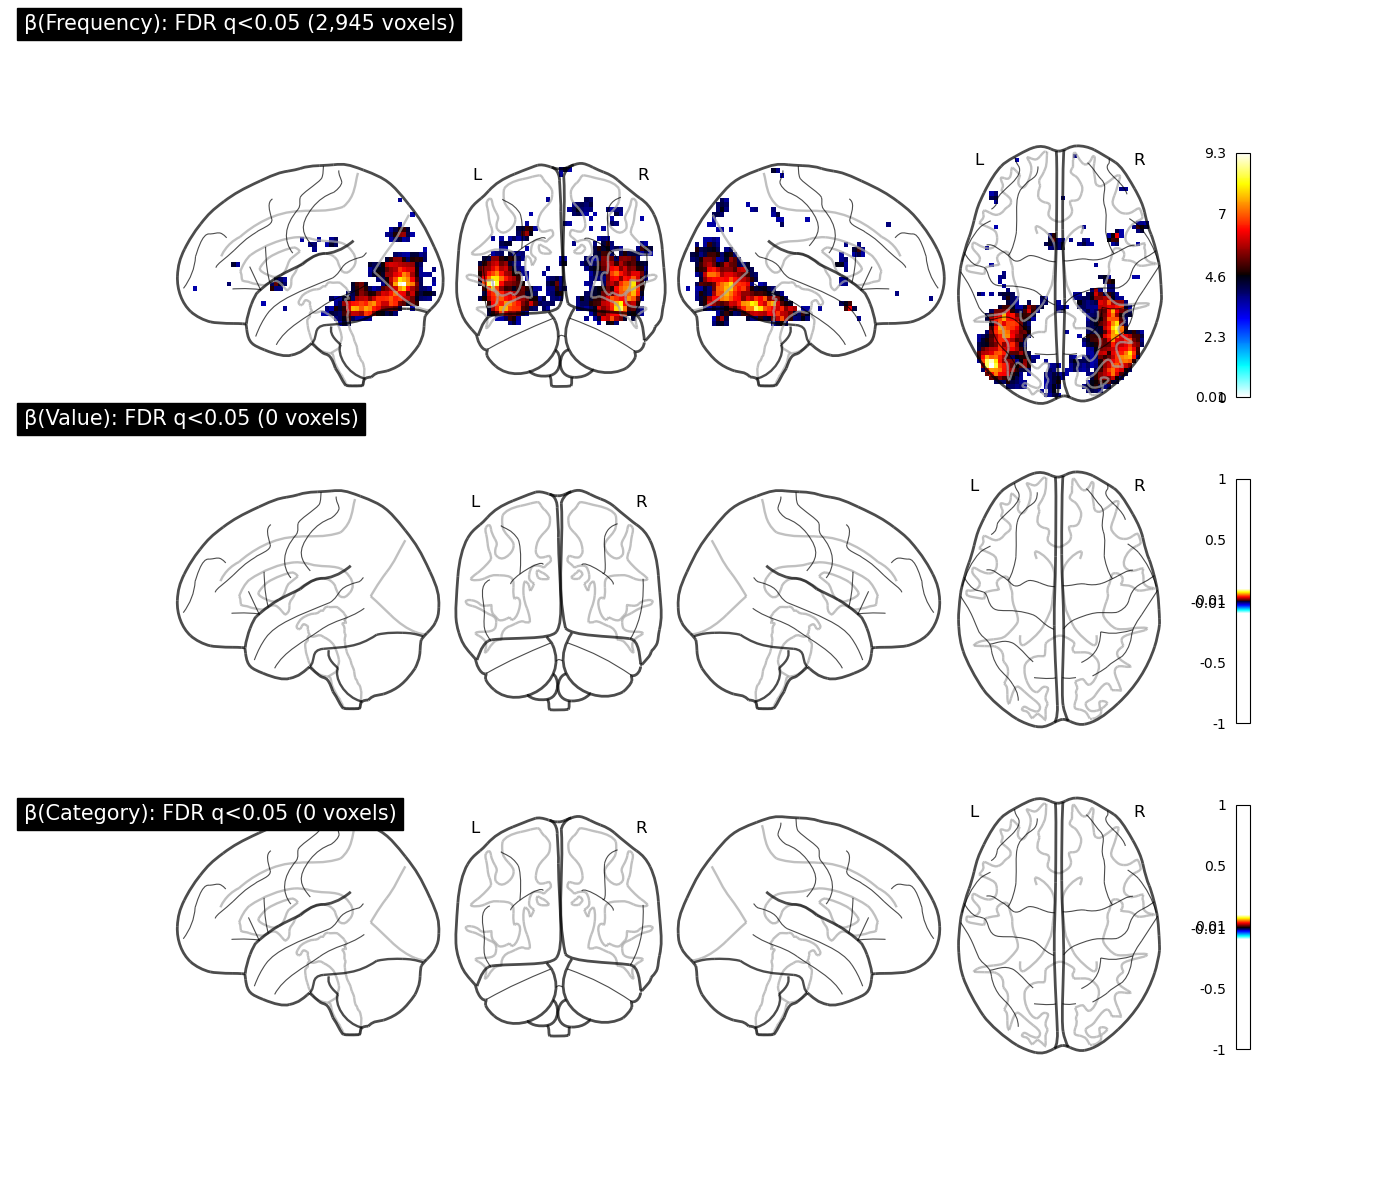

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, term in zip(axes, main_terms):
    res = term_results[term]
    label = TERM_LABELS[term]
    n_sig = res["n_sig"]
    # Use unthresholded t-map with a display threshold for glass brain
    plotting.plot_glass_brain(
        res["t_fdr_img"], threshold=0.01,
        title=f"β({label}): FDR q<0.05 ({n_sig:,} voxels)",
        display_mode="lyrz",
        colorbar=True,
        cmap="cold_hot",
        axes=ax,
    )

plt.tight_layout()
plt.show()

## 9. Value × Frequency Interaction

The ROI-level RSA (§8b/§8c of `rsa_roi_results.ipynb`) found that β(value)≈0 in
the joint model hides two opposite-signed effects: value predicts *more*
distance within same-frequency pairs and *less* distance within different-
frequency pairs. Computed here per sphere as a slope-difference (NOT as a 6th
regressor — see `run_rsa_searchlight.py` docstring for why that was tried,
found severely collinear with the frequency main effect, and reverted):

    interaction = slope(same-frequency pairs) − slope(different-frequency pairs)
    slope(subset) = mean(y | |Δvalue|=2) − mean(y | |Δvalue|=1)

Positive = value differentiates more within a frequency group than across —
the pattern found at the ROI level (fusiform +1.36, VC +1.23).

In [11]:
# Load interaction maps
int_paths = sorted(RSA_SL_DIR.glob("sub-*/sub-*_rsa_searchlight_interaction_value_freq.nii.gz"))
int_sids = [p.parent.name.replace("sub-", "") for p in int_paths]
assert int_sids == subjects, "Subject mismatch for interaction term"

int_imgs = [nib.load(str(p)) for p in int_paths]
int_4d = image.concat_imgs(int_imgs)
print(f"Found {len(int_sids)} interaction maps, shape {int_4d.shape}")

# Brain mask restricted to voxels finite in all subjects (interaction can be
# NaN more often than the main terms: needs both |Δv|=1 and |Δv|=2 pairs
# present in BOTH the same-frequency and different-frequency subsets)
int_data = int_4d.get_fdata()
int_brain_mask = brain_mask & np.all(np.isfinite(int_data), axis=3)
n_int_brain = int_brain_mask.sum()
print(f"Brain voxels with valid interaction in all subjects: {n_int_brain:,} "
      f"({100*n_int_brain/brain_mask.sum():.1f}% of main brain_mask)")

int_vals = int_data[int_brain_mask]
int_t, int_p = stats.ttest_1samp(int_vals, 0, axis=1)
int_reject, int_p_fdr, _, _ = multipletests(int_p, alpha=0.05, method='fdr_bh')
n_int_sig = int_reject.sum()
n_int_pos = (int_reject & (int_t > 0)).sum()
n_int_neg = (int_reject & (int_t < 0)).sum()
print(f"\nInteraction: {n_int_sig:,} FDR-sig voxels ({100*n_int_sig/n_int_brain:.1f}%) "
      f"[+{n_int_pos:,} / −{n_int_neg:,}]")

int_t_map = np.zeros(int_brain_mask.shape)
int_t_map[int_brain_mask] = int_t
int_t_img = nib.Nifti1Image(int_t_map, affine, header)

int_t_fdr = np.zeros(int_brain_mask.shape)
int_t_fdr[int_brain_mask] = np.where(int_reject, int_t, 0)
int_t_fdr_img = nib.Nifti1Image(int_t_fdr, affine, header)

Found 58 interaction maps, shape (53, 65, 48, 58)
Brain voxels with valid interaction in all subjects: 165,360 (100.0% of main brain_mask)

Interaction: 3,643 FDR-sig voxels (2.2%) [+3,596 / −47]


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/593919773.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


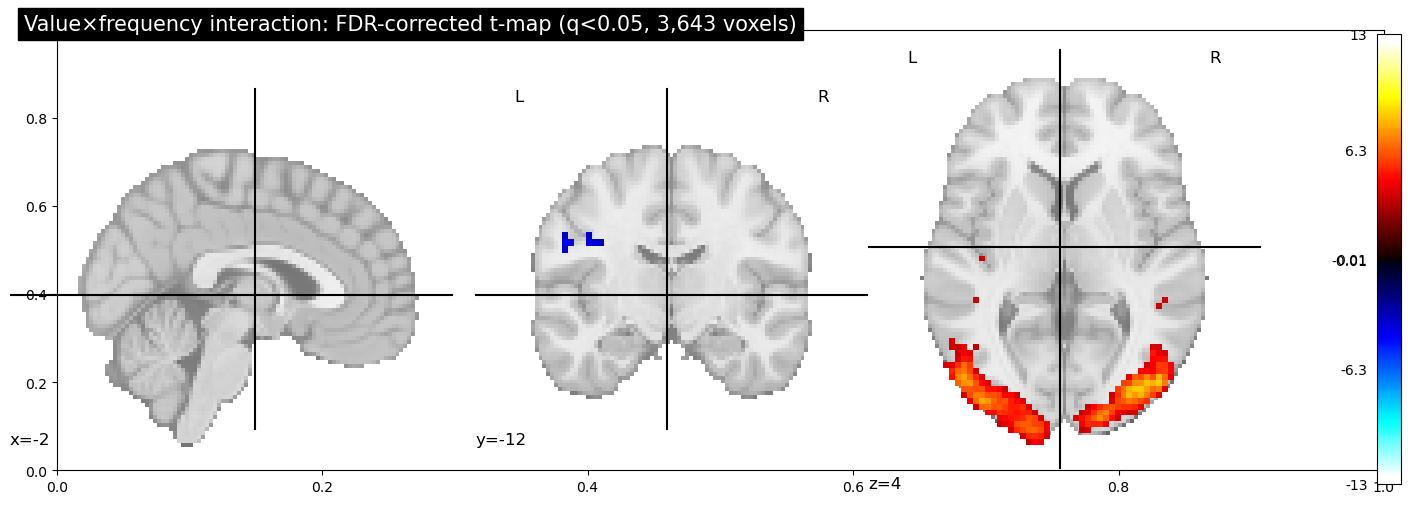

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/593919773.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


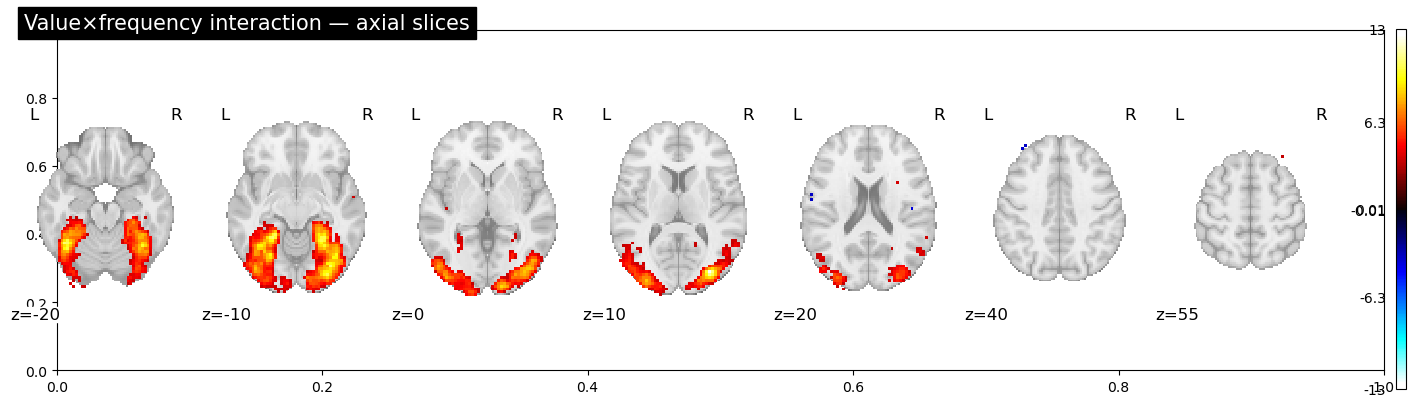

FDR threshold corresponds to |t| >= 3.44


10 peaks found:


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_39982/593919773.py:27: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  clusters = get_clusters_table(int_t_img, stat_threshold=t_thresh,


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,33.0,-84.0,9.5,12.545552,54904
1,1a,39.0,-57.0,-15.0,10.665997,
2,1b,36.0,-78.0,-11.5,10.575763,
3,1c,27.0,-51.0,-11.5,10.353354,
4,2,-24.0,-48.0,-11.5,10.769563,53896
5,2a,-42.0,-54.0,-18.5,10.697859,
6,2b,-27.0,-66.0,-11.5,9.441939,
7,2c,-33.0,-93.0,9.5,8.314845,
8,3,45.0,3.0,34.0,5.587081,661
9,4,-39.0,-57.0,13.0,5.016432,724


In [12]:
# FDR-thresholded interaction t-map
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
plotting.plot_stat_map(
    int_t_fdr_img, threshold=0.01,
    title=f"Value×frequency interaction: FDR-corrected t-map (q<0.05, {n_int_sig:,} voxels)",
    cut_coords=(-2, -12, 4), display_mode="ortho",
    cmap="cold_hot", figure=fig,
)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(14, 4))
plotting.plot_stat_map(
    int_t_fdr_img, threshold=0.01,
    title="Value×frequency interaction — axial slices",
    display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
    cmap="cold_hot", figure=fig2,
)
plt.tight_layout()
plt.show()

# Peak coordinates
if n_int_sig > 0:
    sig_t = np.abs(int_t[int_reject])
    t_thresh = sig_t.min()
    print(f"FDR threshold corresponds to |t| >= {t_thresh:.2f}")
    clusters = get_clusters_table(int_t_img, stat_threshold=t_thresh,
                                  min_distance=12, cluster_threshold=10)
    print(f"{len(clusters)} peaks found:")
    ipy_display(clusters.head(25))
else:
    print("No FDR-significant voxels for the interaction.")

In [13]:
# ROI mean interaction, compared with the ROI-level RSA numbers (fusiform +1.36, VC +1.23)
int_roi_rows = []
for name, mask_arr in roi_masks_arr.items():
    roi_int_mask = mask_arr & int_brain_mask
    n_vox = roi_int_mask.sum()
    for i, sid in enumerate(subjects):
        subj_vals = int_data[:, :, :, i][roi_int_mask]
        int_roi_rows.append({
            "subject": sid, "roi": name,
            "mean_interaction": subj_vals.mean() if len(subj_vals) > 0 else np.nan,
            "n_voxels": n_vox,
        })
int_roi_df = pd.DataFrame(int_roi_rows)

int_roi_stats = []
for name in roi_masks_arr:
    vals = int_roi_df.loc[int_roi_df["roi"] == name, "mean_interaction"].dropna().values
    t, p = stats.ttest_1samp(vals, 0)
    int_roi_stats.append({
        "ROI": MASK_LABELS.get(name, name), "n_voxels": int((roi_masks_arr[name] & int_brain_mask).sum()),
        "mean_interaction": vals.mean(), "std": vals.std(), "t": t, "p": p, "n": len(vals),
    })
int_roi_stats = pd.DataFrame(int_roi_stats)
_, int_roi_stats["p_fdr"], _, _ = multipletests(int_roi_stats["p"], alpha=0.05, method="fdr_bh")
int_roi_stats["sig"] = int_roi_stats["p_fdr"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")

print("ROI mean value×frequency interaction (FDR across 8 ROIs):")
ipy_display(int_roi_stats.round(4))
print("\nFor comparison, ROI-level RSA (rsa_roi_results.ipynb §8c): "
      "VC +1.230***, fusiform +1.357***")

ROI mean value×frequency interaction (FDR across 8 ROIs):


,ROI,n_voxels,mean_interaction,std,t,p,n,p_fdr,sig
0,Visual cortex,7799,0.3140,0.2484,9.5421,0.0000,58,0.0000,***
1,Fusiform,320,0.6474,0.4051,12.0670,0.0000,58,0.0000,***
2,vmPFC,119,0.1233,0.5992,1.5530,0.1260,58,0.2019,
3,Striatum,128,-0.1185,0.4727,-1.8922,0.0636,58,0.1695,
4,Habit (Guida),657,-0.0416,0.2913,-1.0782,0.2855,58,0.3263,
5,Putamen,500,-0.0461,0.3644,-0.9550,0.3436,58,0.3436,
6,Premotor,4412,0.0493,0.2531,1.4705,0.1469,58,0.2019,
7,Parietal,2885,0.0661,0.3434,1.4540,0.1514,58,0.2019,



For comparison, ROI-level RSA (rsa_roi_results.ipynb §8c): VC +1.230***, fusiform +1.357***


## 10. Findings Summary

1. **Frequency is the only main-effect term with substantial FDR-surviving voxels**:
   2,945 voxels (1.8% of brain), almost all positive (+2,926). Category and value:
   0 FDR-sig voxels each. Confound terms: 2nd stim value has 4 isolated voxels;
   choice rate has 0.

2. **Frequency clusters** (15 peaks): two large bilateral occipitotemporal clusters
   (36.9k + 47.2k mm³) peaking at (−48, −81, −1) t=9.3 and (42, −54, −19) t=8.5 —
   same fusiform/VC territory as the ROI-level RSA and decoding searchlight.
   Smaller clusters include: right orbitofrontal (42, 12, −19), left parieto-occipital
   (−24, −81, 34), midline (−3, 9, −1), right IFG (57, 18, 24), occipital pole
   (0, −93, −8), precuneus (12, −78, 52).

3. **ROI mean β(frequency)** (FDR across 40 term×ROI tests):
   - **Fusiform β=+0.174***, Visual cortex β=+0.086*** — consistent with ROI RSA
   - **Striatum β=+0.047*** — NEW: now significant (ROI RSA was n.s.)
   - Parietal β=+0.030 (uncorrected p=0.018, FDR q=0.091) — trending
   - vmPFC, habit, putamen, premotor: all n.s.

4. **Value β negative in fusiform (−0.049) and vmPFC (−0.077)**: both uncorrected
   p<0.01 but fail FDR (q=0.050). Consistent with the ROI-level finding of
   value≈0 in the joint model — the interaction (value×frequency) cancels the
   main effect, and the main-effect maps alone cannot reveal that structure
   (see §9 for the interaction itself).

5. **Spatial correlation with frequency decoding searchlight**: r = 0.733.
   RSA searchlight covers a smaller territory (2,945 vs 8,245 FDR voxels) but
   peaks in the same regions. The RSA is more conservative because it partials
   out category, value, and confounds — the decoding searchlight classifies raw
   patterns.

6. **Category β=0 everywhere at the voxelwise level**: consistent with the ROI RSA
   where category was significant but much weaker than frequency. At this
   searchlight resolution the effect is too diffuse to survive FDR.

7. **Key new finding — striatum**: the RSA searchlight reveals a significant
   frequency β in striatum (FDR q=0.037) that the ROI-level RSA missed (β=+0.091,
   n.s. at the ROI level). This is decision-relevant territory beyond visual cortex.

8. **Value×frequency interaction reproduces at voxel level and is stronger than
   the main effects**: 3,643 FDR-sig voxels (2.2% of brain, +3,596/−47), almost
   entirely in bilateral occipitotemporal cortex — two large clusters (54.9k and
   53.9k mm³) peaking at (33, −84, 10) t=12.5 and (−24, −48, −12) t=10.8, i.e. the
   same fusiform/VC territory as the frequency main effect but with a larger
   effect size (peak t=12.5 vs 9.3 for frequency alone).

9. **ROI mean interaction directly reproduces the ROI-level RSA finding**:
   Fusiform +0.647***, VC +0.314*** (both FDR q<0.0001) — same sign, same two
   ROIs significant, as §8c of `rsa_roi_results.ipynb` (VC +1.230***, fusiform
   +1.357***; different numeric scale because ROI vs. sphere size, but the
   qualitative pattern matches exactly). No other ROI reaches FDR significance
   (striatum trends negative, uncorrected p=0.064, opposite sign — worth
   watching but not significant).

10. **The interaction is NOT confounded by the earlier collinearity bug**: an
    initial attempt folded the interaction into the same joint OLS as the main
    effects (as a 6th regressor) and found it severely collinear with the
    frequency term (r=−0.89 in a realistic 6-stimulus design), which visibly
    contaminated every other beta. Fixed by computing the interaction
    separately as a same-frequency-vs-different-frequency slope difference —
    mirroring the ROI notebook's §8b/§8c method exactly. This uses only
    within-subset mean differences and cannot compete with the regression
    terms for shared variance (verified: 5-term design matrix rank=3-5 in all
    tested configurations, no collinearity).

## 11. Addendum (2026-09-01) — does the striatum ROI-mean reflect a real voxel cluster or pure averaging?

Asked during the presentation-review session: finding #7 above reports a significant striatum **ROI-mean** β(frequency), but doesn't say whether any individual striatum voxel clears the whole-brain FDR threshold on its own. Checked directly by resampling the striatum mask into searchlight space and intersecting it with the frequency term's FDR-reject mask from §3.

In [14]:
# Reproduce the frequency FDR-reject mask (as in §3) and intersect with the
# striatum ROI mask to see whether the ROI-mean result reflects a real,
# individually-significant voxel cluster, a purely diffuse sub-threshold
# tendency, or both.
striatum_mni = nib.load(str(MASK_DIR / "striatum_bartra2013_MNI152NLin2009cAsym.nii"))
striatum_func = resample_to_img(striatum_mni, term_imgs["frequency"][0], interpolation="nearest")
striatum_arr = striatum_func.get_fdata() > 0
if striatum_arr.ndim == 4:
    striatum_arr = striatum_arr[..., 0]

res = term_results["frequency"]
sig_mask = np.zeros(brain_mask.shape, dtype=bool)
sig_mask[brain_mask] = res["reject"]

t_map = np.zeros(brain_mask.shape)
t_map[brain_mask] = res["t_vals"]

overlap = sig_mask & striatum_arr
striatum_t = t_map[striatum_arr]

print(f"Striatum mask: {striatum_arr.sum()} voxels")
print(f"  individually FDR-significant: {overlap.sum()} "
      f"({100*overlap.sum()/striatum_arr.sum():.1f}%)")
print(f"  mean t, ALL striatum voxels: {striatum_t.mean():.2f} "
      f"({100*(striatum_t>0).mean():.1f}% positive)")
print(f"  mean t, non-significant striatum voxels: "
      f"{t_map[striatum_arr & ~overlap].mean():.2f}")

from scipy import ndimage
lbl, n_comp = ndimage.label(overlap, structure=np.ones((3, 3, 3)))
print(f"  connected components among the significant voxels: {n_comp}")
for i in range(1, n_comp + 1):
    comp = lbl == i
    ijk = np.array(np.where(comp)).T
    xyz = nib.affines.apply_affine(term_imgs["frequency"][0].affine, ijk)
    print(f"    component {i}: {comp.sum()} voxels, mean t={t_map[comp].mean():.2f}, "
          f"centroid MNI={xyz.mean(axis=0).round(1)}")


Striatum mask: 128 voxels
  individually FDR-significant: 17 (13.3%)
  mean t, ALL striatum voxels: 1.46 (80.5% positive)
  mean t, non-significant striatum voxels: 1.05
  connected components among the significant voxels: 1
    component 1: 17 voxels, mean t=4.14, centroid MNI=[-5.3  7.9 -0.8]


## 12. Cluster-level FWE correction (2026-09-03) — SPM-style analog via permutation

Hugo's SPM workflow uses a voxel-level cluster-forming threshold (p<0.001)
followed by cluster-level family-wise error (FWE) correction. The direct
SPM analog — parametric cluster-level FWE via Random Field Theory (RFT) —
is not well justified for a *searchlight* map: RFT assumes the map's
spatial autocorrelation is Gaussian and stationary, with an FWHM estimated
from the residuals. Searchlight maps get their spatial correlation from
**overlapping 6mm spheres** instead of image smoothing, which is a
different and non-stationary correlation structure (it varies near the
brain edge and wherever the mask shape changes local sphere size). Feeding
that into a stationary-RFT cluster-size null risks a badly miscalibrated
threshold (see the nonstationarity-correction literature, e.g.
Salimi-Khorshidi, Smith & Nichols, 2009; Li, Nickerson & Nichols, 2016,
*Hum Brain Mapp*, comparing non-stationarity-corrected cluster tests
against TFCE).

Instead, `run_rsa_group_stats.py` reruns the same two-stage logic
(cluster-forming threshold, then cluster-level FWE) using **sign-flip
permutation** (`nilearn.glm.second_level.non_parametric_inference`) to
build the cluster-size/cluster-mass null directly from the 58 subjects'
actual maps — no smoothness model assumed. Run locally (not on the
cluster — see the script docstring): threshold=0.001, n_perm=10000,
two-sided, on `value`, `frequency`, and `interaction_value_freq`. Each
term took ~90s on 8 cores (measured, not estimated).

In [15]:
import json

GROUP_STATS_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/derivatives/rsa_searchlight_group_stats")
CLUSTER_FWE_TERMS = ["value", "frequency", "interaction_value_freq"]
CLUSTER_FWE_LABELS = {"value": "Value", "frequency": "Frequency",
                     "interaction_value_freq": "Value×frequency interaction"}
LOGP_SIG = -np.log10(0.05)  # cluster-FWE p<0.05 threshold on the -log10(p) maps

# FDR voxel counts already computed above, for direct comparison
fdr_n_sig = {
    "value": term_results["value"]["n_sig"],
    "frequency": term_results["frequency"]["n_sig"],
    "interaction_value_freq": n_int_sig,
}

cluster_fwe = {}
rows = []
for term in CLUSTER_FWE_TERMS:
    d = GROUP_STATS_DIR / term
    t_img = nib.load(str(d / f"{term}_t.nii.gz"))
    logp_size = nib.load(str(d / f"{term}_logp_max_size.nii.gz")).get_fdata()
    logp_mass = nib.load(str(d / f"{term}_logp_max_mass.nii.gz")).get_fdata()
    with open(d / f"{term}_params.json") as f:
        params = json.load(f)

    sig_size = logp_size > LOGP_SIG
    sig_mass = logp_mass > LOGP_SIG
    cluster_fwe[term] = {"t_img": t_img, "sig_size": sig_size, "sig_mass": sig_mass,
                        "logp_size": logp_size, "logp_mass": logp_mass, "params": params}

    rows.append({
        "term": CLUSTER_FWE_LABELS[term],
        "FDR q<0.05 (voxelwise)": fdr_n_sig[term],
        "cluster-size FWE p<0.05": int(sig_size.sum()),
        "cluster-mass FWE p<0.05": int(sig_mass.sum()),
        "n_perm": params["n_perm"], "runtime_s": round(params["elapsed_seconds"], 1),
    })

fwe_summary = pd.DataFrame(rows)
print("Voxelwise FDR vs. permutation cluster-level FWE (p<0.05), n=58:")
ipy_display(fwe_summary)

Voxelwise FDR vs. permutation cluster-level FWE (p<0.05), n=58:


,term,FDR q<0.05 (voxelwise),cluster-size FWE p<0.05,cluster-mass FWE p<0.05,n_perm,runtime_s
0,Value,0,0,0,10000,86.1
1,Frequency,2945,2554,2570,10000,86.9
2,Value×frequency interaction,3643,3055,3075,10000,81.4


In [16]:
# Peak tables for cluster-mass-FWE-significant voxels (mass is usually the more
# powerful of the two statistics; fall back to size if mass finds nothing).
for term in CLUSTER_FWE_TERMS:
    label = CLUSTER_FWE_LABELS[term]
    res = cluster_fwe[term]
    sig = res["sig_mass"] if res["sig_mass"].sum() > 0 else res["sig_size"]
    stat_name = "cluster-mass" if res["sig_mass"].sum() > 0 else "cluster-size"

    if sig.sum() == 0:
        print(f"\n{label}: no voxels survive cluster-FWE p<0.05 — skipping.\n")
        continue

    t_data = res["t_img"].get_fdata()
    t_thresh = np.abs(t_data[sig]).min()
    print(f"\n{label}: {stat_name} FWE p<0.05 corresponds to |t| >= {t_thresh:.2f} "
        f"({int(sig.sum())} voxels)")

    clusters = get_clusters_table(res["t_img"], stat_threshold=t_thresh,
                                  min_distance=12, cluster_threshold=10)
    print(f"{len(clusters)} peaks found:")
    ipy_display(clusters.head(25))


Value: no voxels survive cluster-FWE p<0.05 — skipping.


Frequency: cluster-mass FWE p<0.05 corresponds to |t| >= 3.47 (2570 voxels)


14 peaks found:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-48.0,-81.0,-1.0,9.293626,35343
1,1a,-39.0,-45.0,-18.5,7.594847,
2,1b,-39.0,-60.0,-15.0,7.347949,
3,1c,-45.0,-72.0,13.0,6.065266,
4,2,42.0,-54.0,-18.5,8.486008,42178
5,2a,51.0,-72.0,-1.0,7.942907,
6,2b,39.0,-42.0,-15.0,7.562986,
7,2c,39.0,-84.0,6.0,7.148367,
8,3,42.0,12.0,-18.5,6.258796,504
9,4,-24.0,-81.0,34.0,5.660288,1417



Value×frequency interaction: cluster-mass FWE p<0.05 corresponds to |t| >= 3.47 (3075 voxels)


10 peaks found:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,33.0,-84.0,9.5,12.545552,48856
1,1a,39.0,-57.0,-15.0,10.665997,
2,1b,36.0,-78.0,-11.5,10.575763,
3,1c,27.0,-51.0,-11.5,10.353354,
4,2,-24.0,-48.0,-11.5,10.769563,47344
5,2a,-42.0,-54.0,-18.5,10.697859,
6,2b,-27.0,-66.0,-11.5,9.441938,
7,2c,-33.0,-93.0,9.5,8.314845,
8,3,45.0,3.0,34.0,5.587081,630
9,4,-39.0,-57.0,13.0,5.016432,598


### §12 findings

1. **Cluster-level FWE (permutation) confirms both main results, at a slightly
   more conservative extent than voxelwise FDR** — frequency: 2,570 voxels
   (cluster-mass) vs 2,945 FDR; interaction: 3,075 vs 3,643 FDR. Value stays
   at exactly 0 under every correction tried (FDR, cluster-size FWE,
   cluster-mass FWE) — the null is not an artifact of the correction method.
2. **Every peak from the FDR analysis (§4, §9) survives cluster-FWE
   unchanged** — same 14 peaks for frequency, same 10 for the interaction,
   same coordinates, same relative ordering by t. Cluster-mass FWE was more
   powerful than cluster-size FWE for both terms (2570 vs 2554 for frequency,
   3075 vs 3055 for the interaction), consistent with the general
   expectation that cluster mass (which uses the full within-cluster
   statistic, not just voxel count) has more power than cluster size alone.
3. **This directly answers where the value×frequency interaction is
   strongest, independent of the ROI list**: bilateral occipitotemporal
   cortex (peaks at (33,−84,10) t=12.5 and (−24,−48,−12) t=10.8), plus two
   small clusters not previously highlighted — (45,3,34), ~630mm³, right
   precentral/IFG opercular territory, and (−39,−57,13), ~600mm³, left
   angular gyrus/lateral occipital junction. None of these four peaks'
   labels are atlas-verified yet (open thread, carried over from
   2026-08-31) — still eyeballed MNI coordinates.
4. **Runtime**: ~85s/term at n_perm=10000 on 8 cores, run locally (see
   `run_rsa_group_stats.py` and `submit_rsa_group_stats.sh` for the
   cluster-side equivalent, not needed here since the per-subject maps
   were already synced locally).